In [1]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the Twitter Airline Sentiment dataset
df = pd.read_csv('Tweets.csv')
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
# Checking the number of rows and columns in the dataset
print(df.shape)

(14640, 15)


In [4]:
# Checking the column names and data types
df.dtypes

tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                       str
dtype: object

In [5]:
# Checking for missing values in each column
df.isnull().sum()

tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [6]:
# Keeping only the relevant columns for sentiment analysis and dropping irrelevant ones
df = df[['airline_sentiment', 'airline', 'negativereason', 'text']]
df.head()

,airline_sentiment,airline,negativereason,text
0,neutral,Virgin America,NaN,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,NaN,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,NaN,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,Bad Flight,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,Can't Tell,@VirginAmerica and it's a really big bad thing...


In [7]:
# Checking the distribution of sentiments in the dataset
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

In [8]:
# Checking the number of tweets per airline
df['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

In [9]:
# Checking the most common reasons for negative tweets
df['negativereason'].value_counts()

negativereason
Customer Service Issue         2910
Late Flight                    1665
Can't Tell                     1190
Cancelled Flight                847
Lost Luggage                    724
Bad Flight                      580
Flight Booking Problems         529
Flight Attendant Complaints     481
longlines                       178
Damaged Luggage                  74
Name: count, dtype: int64

In [10]:
# Applying TextBlob to analyse sentiment of each tweet
def get_textblob_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0.1:
        return 'positive'
    elif analysis.sentiment.polarity < -0.1:
        return 'negative'
    else:
        return 'neutral'

df['textblob_sentiment'] = df['text'].apply(get_textblob_sentiment)
df[['text', 'airline_sentiment', 'textblob_sentiment']].head(10)

,text,airline_sentiment,textblob_sentiment
0,@VirginAmerica What @dhepburn said.,neutral,neutral
1,@VirginAmerica plus you've added commercials t...,positive,neutral
2,@VirginAmerica I didn't today... Must mean I n...,neutral,negative
3,@VirginAmerica it's really aggressive to blast...,negative,neutral
4,@VirginAmerica and it's a really big bad thing...,negative,negative
5,@VirginAmerica seriously would pay $30 a fligh...,negative,negative
6,"@VirginAmerica yes, nearly every time I fly VX...",positive,positive
7,@VirginAmerica Really missed a prime opportuni...,neutral,positive
8,"@virginamerica Well, I didn't…but NOW I DO! :-D",positive,positive
9,"@VirginAmerica it was amazing, and arrived an ...",positive,positive


In [11]:
# Comparing TextBlob predictions with the original sentiment labels
comparison = pd.crosstab(df['airline_sentiment'], df['textblob_sentiment'])
comparison

textblob_sentiment,negative,neutral,positive
airline_sentiment,,,
negative,2622,4524,2032
neutral,224,2009,866
positive,63,582,1718


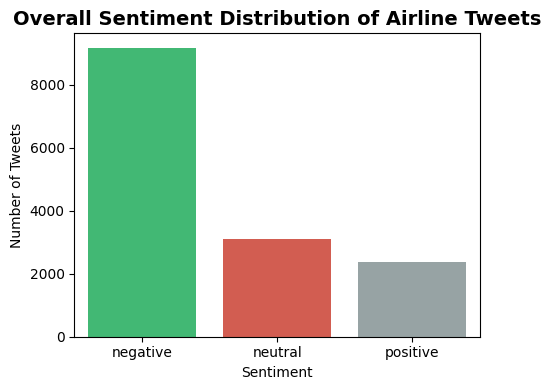

In [12]:
# Visualizing the overall distribution of airline sentiments
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='airline_sentiment', hue='airline_sentiment',
              palette=['#E74C3C', '#95A5A6', '#2ECC71'], legend=False,
              order=['negative', 'neutral', 'positive'])
plt.title('Overall Sentiment Distribution of Airline Tweets', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig('sentiment1_overall_distribution.png', dpi=150)
plt.show()

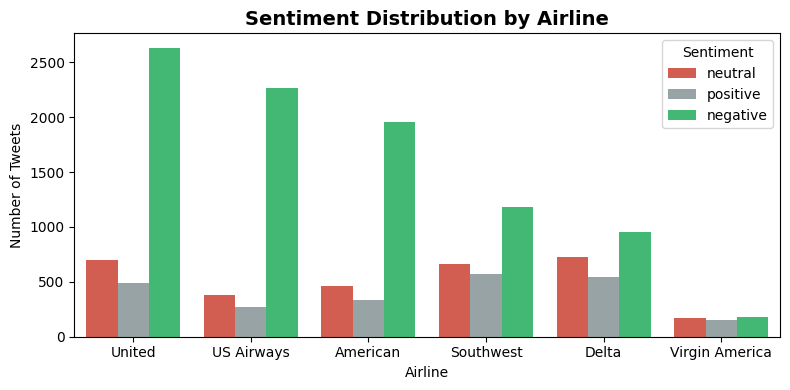

In [13]:
# Visualizing sentiment distribution for each airline
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='airline', hue='airline_sentiment',
              palette=['#E74C3C', '#95A5A6', '#2ECC71'],
              order=df['airline'].value_counts().index)
plt.title('Sentiment Distribution by Airline', fontsize=14, fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('sentiment2_by_airline.png', dpi=150)
plt.show()

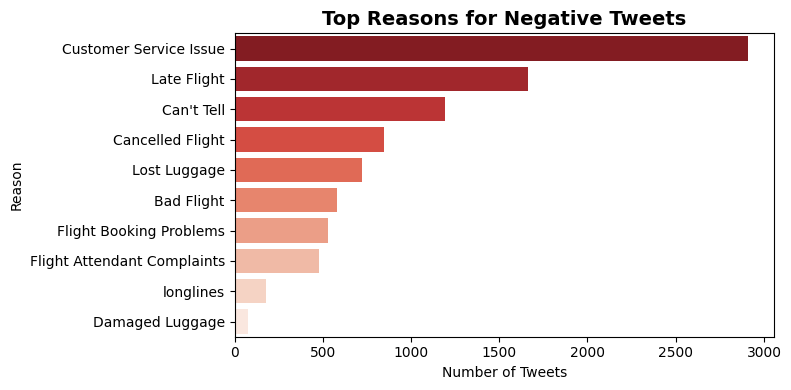

In [14]:
# Visualizing the top reasons for negative tweets
negative_reasons = df['negativereason'].value_counts()

plt.figure(figsize=(8, 4))
sns.barplot(x=negative_reasons.values, y=negative_reasons.index, hue=negative_reasons.index,
            palette='Reds_r', legend=False)
plt.title('Top Reasons for Negative Tweets', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tweets')
plt.ylabel('Reason')
plt.tight_layout()
plt.savefig('sentiment3_negative_reasons.png', dpi=150)
plt.show()

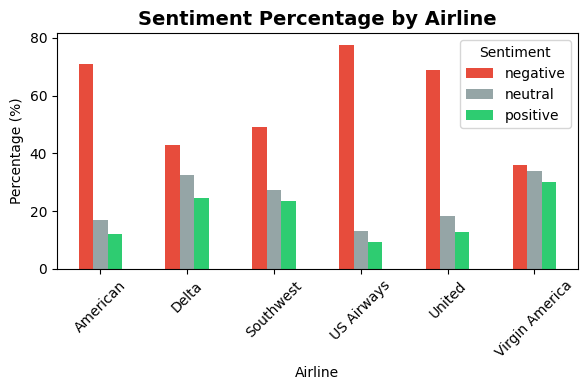

In [16]:
# Visualizing the sentiment percentage for each airline
airline_sentiment = df.groupby(['airline', 'airline_sentiment']).size().unstack()
airline_sentiment_pct = airline_sentiment.div(airline_sentiment.sum(axis=1), axis=0) * 100

airline_sentiment_pct.plot(kind='bar', figsize=(6, 4), 
                           color=['#E74C3C', '#95A5A6', '#2ECC71'])
plt.title('Sentiment Percentage by Airline', fontsize=14, fontweight='bold')
plt.xlabel('Airline')
plt.ylabel('Percentage (%)')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sentiment4_sentiment_percentage.png', dpi=150)
plt.show()

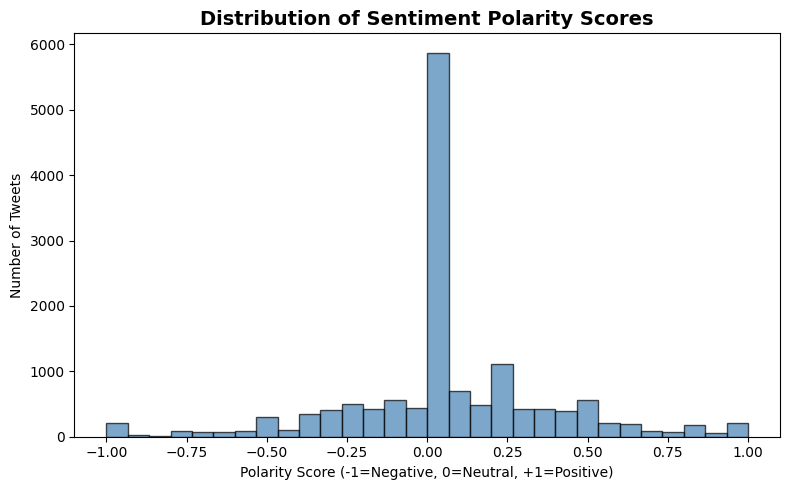

In [17]:
# Visualizing the distribution of TextBlob polarity scores
df['polarity'] = df['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

plt.figure(figsize=(8, 5))
plt.hist(df['polarity'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Sentiment Polarity Scores', fontsize=14, fontweight='bold')
plt.xlabel('Polarity Score (-1=Negative, 0=Neutral, +1=Positive)')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig('sentiment5_polarity_distribution.png', dpi=150)
plt.show()

In [20]:
print("=" * 55)
print("SENTIMENT ANALYSIS SUMMARY")
print("Twitter US Airline Sentiment Dataset")
print("=" * 55)
print("Dataset: 14,640 tweets, 15 features")
print("Source: Kaggle - Crowdflower Twitter Airline Sentiment")
print("")
print("SENTIMENT DISTRIBUTION:")
print("Negative tweets: 9,178 (62.7%)")
print("Neutral tweets:  3,099 (21.2%)")
print("Positive tweets: 2,363 (16.1%)")
print("")
print("TWEETS PER AIRLINE:")
print("United Airlines:  3,822 tweets")
print("US Airways:       2,913 tweets")
print("American:         2,759 tweets")
print("Southwest:        2,420 tweets")
print("Delta:            2,222 tweets")
print("Virgin America:     504 tweets")
print("")
print("TOP NEGATIVE REASONS:")
print("1. Customer Service Issue - 2,910 tweets")
print("2. Late Flight            - 1,665 tweets")
print("3. Cancelled Flight       -   847 tweets")
print("")
print("KEY INSIGHTS:")
print("1. Over 62% of airline tweets are negative")
print("2. Customer service is the biggest complaint")
print("3. United Airlines receives the most tweets")
print("4. Virgin America has the smallest tweet volume")
print("5. TextBlob and human labels sometimes disagree")
print("")
print("TOOLS USED: TextBlob, Matplotlib, Seaborn")
print("=" * 55)

SENTIMENT ANALYSIS SUMMARY
Twitter US Airline Sentiment Dataset
Dataset: 14,640 tweets, 15 features
Source: Kaggle - Crowdflower Twitter Airline Sentiment

SENTIMENT DISTRIBUTION:
Negative tweets: 9,178 (62.7%)
Neutral tweets:  3,099 (21.2%)
Positive tweets: 2,363 (16.1%)

TWEETS PER AIRLINE:
United Airlines:  3,822 tweets
US Airways:       2,913 tweets
American:         2,759 tweets
Southwest:        2,420 tweets
Delta:            2,222 tweets
Virgin America:     504 tweets

TOP NEGATIVE REASONS:
1. Customer Service Issue - 2,910 tweets
2. Late Flight            - 1,665 tweets
3. Cancelled Flight       -   847 tweets

KEY INSIGHTS:
1. Over 62% of airline tweets are negative
2. Customer service is the biggest complaint
3. United Airlines receives the most tweets
4. Virgin America has the smallest tweet volume
5. TextBlob and human labels sometimes disagree

TOOLS USED: TextBlob, Matplotlib, Seaborn
